### [ 컨투어 찾기와 그리기 ] <hr>

In [ ]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

<module 'cv_utils' from 'C:\\KDT14\\7_CV\\cv_utils.py'>

도형의 갯수: 3(3)


(np.float64(-0.5), np.float64(422.5), np.float64(149.5), np.float64(-0.5))

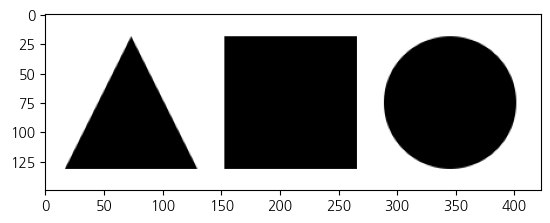

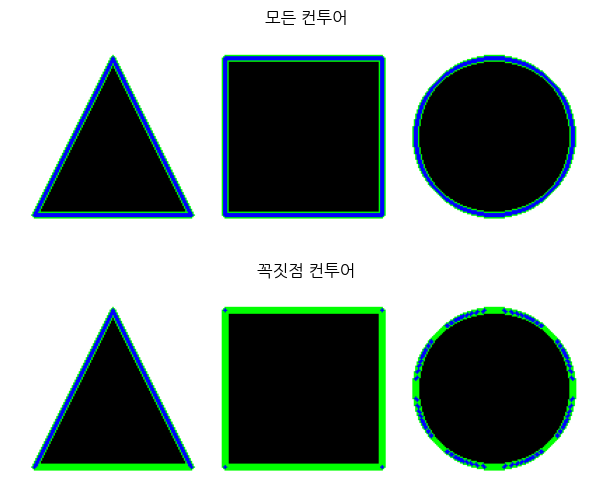

In [ ]:
import cv2
import numpy as np

img = cv2.imread('./shapes.png')
img2 = img.copy()

plt.imshow(img)

# 그레이 스케일로 변환 
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 스레시홀드로 바이너리 이미지로 만들어서 검은배경에 흰색전경으로 반전
ret, imthres = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY_INV)

# 모든 좌표 반환 
contour, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, \
                                                 cv2.CHAIN_APPROX_NONE)[-2:]


# 꼭지점 좌표만 반환 
contour2, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, \
                                                cv2.CHAIN_APPROX_SIMPLE)[-2:]

# 각각의 컨투의 갯수 출력
print('도형의 갯수: %d(%d)'% (len(contour), len(contour2)))

# 모든 좌표를 갖는 컨투어 그리기, 초록색 
cv2.drawContours(img, contour, -1, (0,255,0), 4)

# 꼭지점 좌표만을 갖는 컨투어 그리기, 초록색 
cv2.drawContours(img2, contour2, -1, (0,255,0), 4)

# 컨투어 모든 좌표를 작은 파랑색 점(원)으로 표시 
for i in contour:
    for j in i:
        cv2.circle(img, tuple(j[0]), 1, (0,0,255), -1) 

# 컨투어 꼭지점 좌표를 작은 파랑색 점(원)으로 표시
for i in contour2:
    for j in i:
        cv2.circle(img2, tuple(j[0]), 1, (0,0,255), -1) 

# 결과 출력
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.imshow(img)
plt.title('모든 컨투어')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2)
plt.title('꼭짓점 컨투어')
plt.axis('off')

### [컨투어 계층 트리] <hr>

3 [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [-1  1 -1 -1]]]
6 [[[ 2 -1  1 -1]
  [-1 -1 -1  0]
  [ 4  0  3 -1]
  [-1 -1 -1  2]
  [-1  2  5 -1]
  [-1 -1 -1  4]]]


(np.float64(-0.5), np.float64(420.5), np.float64(153.5), np.float64(-0.5))

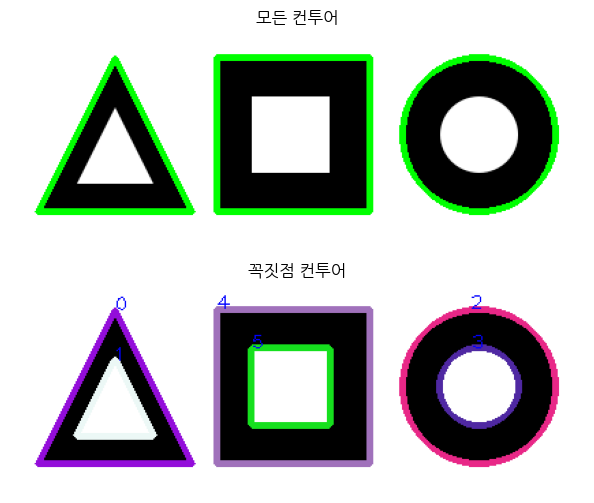

In [ ]:

# 영상 읽기
img = cv2.imread('./shapes_donut.png')
img2 = img.copy()
# 바이너리 이미지로 변환
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, imthres = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY_INV)

# 가장 바깥 컨투어만 수집   
contour, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, \
                                                cv2.CHAIN_APPROX_NONE)[-2:]
# 컨투어 갯수와 계층 트리 출력 
print(len(contour), hierarchy)

# 모든 컨투어를 트리 계층 으로 수집 
contour2, hierarchy = cv2.findContours(imthres, cv2.RETR_TREE, \
                                            cv2.CHAIN_APPROX_SIMPLE)[-2:]
# 컨투어 갯수와 계층 트리 출력 
print(len(contour2), hierarchy)

# 가장 바깥 컨투어만 그리기 
cv2.drawContours(img, contour, -1, (0,255,0), 3)
# 모든 컨투어 그리기
for idx, cont in enumerate(contour2): 
    # 랜덤한 컬러 추출 -
    color = [int(i) for i in np.random.randint(0,255, 3)]
    # 컨투어 인덱스 마다 랜덤한 색상으로 그리기 
    cv2.drawContours(img2, contour2, idx, color, 3)
    # 컨투어 첫 좌표에 인덱스 숫자 표시 
    cv2.putText(img2, str(idx), tuple(cont[0][0]), cv2.FONT_HERSHEY_PLAIN, \
                                                            1, (0,0,255))

# 결과 출력
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.imshow(img)
plt.title('모든 컨투어')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2)
plt.title('꼭짓점 컨투어')
plt.axis('off')

### [ 모멘트 이용한 중심점, 넓이, 둘레길이 ] <hr>

area:9870.00
area:12544.00
area:6216.00


(np.float64(-0.5), np.float64(422.5), np.float64(149.5), np.float64(-0.5))

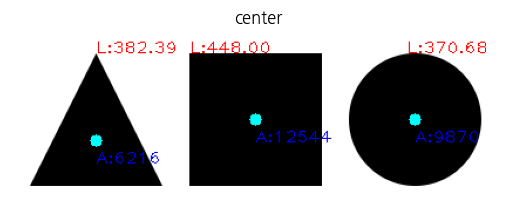

In [ ]:

img = cv2.imread('./shapes.png')
# 그레이 스케일 변환
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 바이너리 스케일 변환
ret, th = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY_INV)
# 컨투어 찾기
contours, hierachy = cv2.findContours(th, cv2.RETR_EXTERNAL, \
                                            cv2.CHAIN_APPROX_SIMPLE)[-2:]

# 각 도형의 컨투어에 대한 루프
for c in contours:
    # 모멘트 계산
    mmt = cv2.moments(c)
    # m10/m00, m01/m00  중심점 계산
    cx = int(mmt['m10']/mmt['m00'])
    cy = int(mmt['m01']/mmt['m00'])
    # 영역 넓이
    a = mmt['m00']
    # 영역 외곽선 길이
    l = cv2.arcLength(c, True)
    # 중심점에 노란색 점 그리기
    cv2.circle(img, (cx, cy), 5, (0, 255, 255), -1)
    # 중심점 근처에 넓이 그리기
    cv2.putText(img, "A:%.0f"%a, (cx, cy+20) , cv2.FONT_HERSHEY_PLAIN, \
                                                            1, (0,0,255))
    # 컨투어 시작점에 길이 그리기
    cv2.putText(img, "L:%.2f"%l, tuple(c[0][0]), cv2.FONT_HERSHEY_PLAIN, \
                                                            1, (255,0,0))
    # 함수로 컨투어 넓이 계산해서 출력
    print("area:%.2f"%cv2.contourArea(c, False))

# 결과 출력
plt.imshow(img)
plt.title('center')
plt.axis('off')


### [ 컨투어 감싸는 도형 그리기 ] <hr>

In [ ]:

# 이미지 읽어서 그레이스케일 변환, 바이너리 스케일 변환
img = cv2.imread("./lightning.png")
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

contours, hr = cv2.findContours(th, cv2.RETR_EXTERNAL, \
                                        cv2.CHAIN_APPROX_SIMPLE)[-2:]
contr = contours[0]
print(type(contr), contr.shape, contr.dtype)

x,y,w,h = cv2.boundingRect(contr)
cv2.rectangle(img, (x,y), (x+w, y+h), (0,0,0), 3)

rect = cv2.minAreaRect(contr)
box = cv2.boxPoints(rect)   
box = np.int32(box)          
cv2.drawContours(img, [box], -1, (0,255,0), 3)

(x,y), radius = cv2.minEnclosingCircle(contr)
cv2.circle(img, (int(x), int(y)), int(radius), (255,0,0), 2)

ret, tri = cv2.minEnclosingTriangle(np.float32(contr))
cv2.polylines(img, [np.int32(tri)], True, (255,0,255), 2)

ellipse = cv2.fitEllipse(contr)
cv2.ellipse(img, ellipse, (0,255,255), 3)

# 2D 배열 형태([[값]])로 나오는 반환값에서 [0]을 붙여 순수 숫자 값만 쏙 빼옵니다.
vx, vy, x, y = cv2.fitLine(contr, cv2.DIST_L2, 0, 0.01, 0.01)
vx, vy, x, y = vx[0], vy[0], x[0], y[0]

cols,rows = img.shape[:2]
cv2.line(img, (0, int(0-x*(vy/vx) + y)), (cols-1, int((cols-x)*(vy/vx) + y)), (0,0,255),2)

cv_utils.printPlots(1, 1, ['Bound Fit shapes'], [img])

<class 'numpy.ndarray'> (152, 1, 2) int32


error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'line'
> Overload resolution failed:
>  - Can't parse 'pt1'. Sequence item with index 1 has a wrong type
>  - Can't parse 'pt1'. Sequence item with index 1 has a wrong type


### [ 컨투어 단순화 ] <hr>

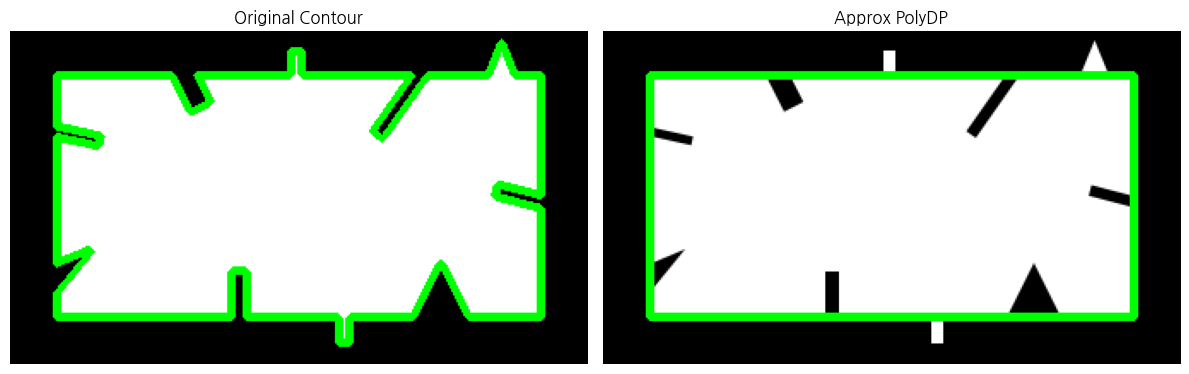

In [ ]:


img = cv2.imread('./bad_rect.png')
img2 = img.copy()

# 그레이스케일과 바이너리 스케일 변환
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
ret, th = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

# 컨투어 찾기
contours, hierarchy = cv2.findContours(
    th, 
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)[-2:]

contour = contours[0]

# 전체 둘레의 0.05로 오차 범위 지정
epsilon = 0.05 * cv2.arcLength(contour, True)

# 근사 컨투어 계산
approx = cv2.approxPolyDP(contour, epsilon, True)

# 각각 컨투어 선 그리기
cv2.drawContours(img, [contour], -1, (0, 255, 0), 3)
cv2.drawContours(img2, [approx], -1, (0, 255, 0), 3)

# BGR -> RGB 변환
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# plt로 결과 출력
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Contour")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Approx PolyDP")
plt.axis("off")

plt.tight_layout()
plt.show()

### [ 볼록 선체 ] <hr>

원본 컨투어 볼록 여부: False
볼록 선체 볼록 여부: True


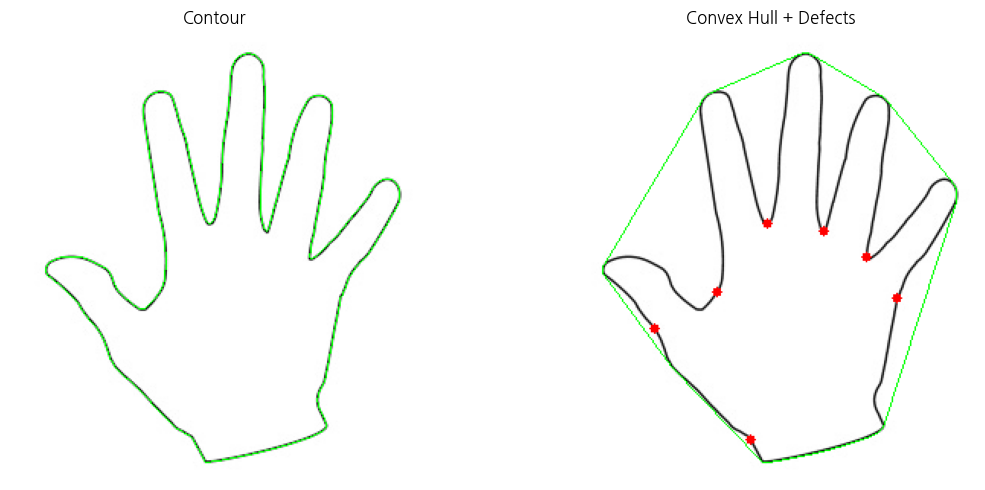

In [ ]:

img = cv2.imread('./hand.jpg')
img2 = img.copy()

# 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 이진화: 손 부분을 흰색 전경으로 만들기
ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 컨투어 찾기
contours, hierarchy = cv2.findContours(
    th,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)[-2:]

# 가장 큰 컨투어 선택
cntr = max(contours, key=cv2.contourArea)

# 원본 컨투어 그리기
cv2.drawContours(img, [cntr], -1, (0, 255, 0), 1)

# 볼록 선체 찾기: 좌표 기준
hull = cv2.convexHull(cntr)
cv2.drawContours(img2, [hull], -1, (0, 255, 0), 1)

# 볼록 여부 확인
print("원본 컨투어 볼록 여부:", cv2.isContourConvex(cntr))
print("볼록 선체 볼록 여부:", cv2.isContourConvex(hull))

# 볼록 선체 찾기: 인덱스 기준
hull2 = cv2.convexHull(cntr, returnPoints=False)

# 볼록 결함 찾기
defects = cv2.convexityDefects(cntr, hull2)

# 결함 지점 표시
if defects is not None:
    for i in range(defects.shape[0]):
        startP, endP, farthestP, distance = defects[i, 0]

        farthest = tuple(cntr[farthestP][0])
        dist = distance / 256.0

        if dist > 1:
            cv2.circle(img2, farthest, 3, (0, 0, 255), -1)

# BGR -> RGB 변환
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# plt 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Contour")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Convex Hull + Defects")
plt.axis("off")

plt.tight_layout()
plt.show()

### [ 도형 매칭 ] <hr>

In [ ]:

# 매칭을 위한 이미지 읽기
target = cv2.imread('./4star.jpg')              # 매칭 대상
shapes = cv2.imread('./shapestomatch.jpg')      # 여러 도형

# 원본 복사
shapes_result = shapes.copy()

# 그레이스케일 변환
targetGray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
shapesGray = cv2.cvtColor(shapes, cv2.COLOR_BGR2GRAY)

# 바이너리 변환
ret, targetTh = cv2.threshold(targetGray, 127, 255, cv2.THRESH_BINARY_INV)
ret, shapesTh = cv2.threshold(shapesGray, 127, 255, cv2.THRESH_BINARY_INV)

# 컨투어 찾기
cntrs_target, _ = cv2.findContours(
    targetTh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)[-2:]

cntrs_shapes, _ = cv2.findContours(
    shapesTh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)[-2:]

# 기준 도형 컨투어
target_contour = cntrs_target[0]

# 각 도형과 매칭
matchs = []

for contr in cntrs_shapes:
    match = cv2.matchShapes(
        target_contour,
        contr,
        cv2.CONTOURS_MATCH_I2,
        0.0
    )

    matchs.append((match, contr))

    # 매칭 점수 표시
    x, y = contr[0][0]
    cv2.putText(
        shapes_result,
        f"{match:.2f}",
        (x, y),
        cv2.FONT_HERSHEY_PLAIN,
        1,
        (0, 0, 255),
        1
    )

# 매칭 점수가 작은 순서로 정렬
matchs.sort(key=lambda x: x[0])

# 가장 비슷한 도형 표시
cv2.drawContours(shapes_result, [matchs[0][1]], -1, (0, 255, 0), 3)

# BGR → RGB 변환
target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
shapes_rgb = cv2.cvtColor(shapes_result, cv2.COLOR_BGR2RGB)

# plt 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(target_rgb)
plt.title("Target Shape")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(shapes_rgb)
plt.title("Matched Shape")
plt.axis("off")

plt.tight_layout()
plt.show()

## [ 허프 변환 ] <hr>

In [ ]:

img = cv2.imread('./sudoku.jpg')
img2 = img.copy()

h, w = img.shape[:2]

# 그레이스케일 변환
imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 엣지 검출
edges = cv2.Canny(imgray, 100, 200)

# 허프 선 검출
lines = cv2.HoughLines(edges, 1, np.pi / 180, 130)

if lines is not None:
    for line in lines:
        r, theta = line[0]  # r: 원점으로부터 거리, theta: 각도

        # cos, sin 계산
        tx, ty = np.cos(theta), np.sin(theta)

        # 기준점 좌표
        x0, y0 = tx * r, ty * r

        # 기준점 표시
        cv2.circle(img2, (int(abs(x0)), int(abs(y0))), 3, (0, 0, 255), -1)

        # 직선을 길게 그리기 위한 양 끝점 계산
        x1 = int(x0 + w * (-ty))
        y1 = int(y0 + h * tx)

        x2 = int(x0 - w * (-ty))
        y2 = int(y0 - h * tx)

        # 선 그리기
        cv2.line(img2, (x1, y1), (x2, y2), (0, 255, 0), 1)

# BGR → RGB 변환
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# 결과 출력
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("Hough Lines")
plt.axis("off")

plt.tight_layout()
plt.show()